# Step 5 — ML: Predicting Salary Band from Posting Features

**Target choice:** the project brief allows predicting either (a) salary band or
(b) seniority level. This notebook predicts **salary band** (Low / Mid / High,
defined as tertiles of `salary_avg` among the 1,122 postings that disclose pay),
not seniority, for two reasons:

1. Salary is **real, employer-provided data**. Seniority in this project is
   *itself* an NLP rule we wrote (`nlp/seniority.py`) — training a model to
   predict our own regex output would mostly be testing whether the model can
   reverse-engineer a keyword rule, which is a much weaker ML story.
2. "Salary band" (not raw-rupee regression) matches the project brief's own
   phrasing, and is more robust to the wide, noisy salary ranges some postings
   list (see Step 4 notebook) than predicting an exact number would be.

Seniority is still used — as an **input feature**, alongside role, city, and
extracted skills, since it's a legitimate (if imperfect) signal a recruiter
would also use.


In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DB_PATH = "../data/jobdatadigest.db"
conn = sqlite3.connect(DB_PATH)
pd.set_option("display.width", 120)

BLUE_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
INK_PRIMARY = "#0b0b0b"


## 1. Data leakage checklist

Before touching features, the explicit list of what's excluded and why:

| Excluded | Reason |
|---|---|
| `salary_min`, `salary_max`, `salary_avg` | These define the target itself. |
| `posting_id`, `company`, `redirect_url` | Identifiers, no predictive meaning. |
| `title`, `description` (raw text) | Could indirectly restate salary or the label-generating keywords; we only use *derived* features from them (description length, extracted skills, inferred seniority), never the raw text itself. |
| `pull_date`, `created_date` | Timestamps of ingestion/posting, not job characteristics. |
| `location_raw`, `state`, `category` | `category` is 94% the single constant value "IT Jobs" post-filtering (near-zero variance); `location_raw`/`state` are redundant with the `city` field we do use. |

One more leakage-adjacent decision made explicit: **which 15 skills to include
as binary features was chosen by their overall frequency across all 4,858
postings** (a property of X, not of the salary label), not by which skills
correlate with salary. Picking features because they correlate with y would
leak label information into feature selection even before model fitting.


In [2]:
postings = pd.read_sql_query('''
    SELECT posting_id, primary_role, city, seniority, description_length,
           contract_type, contract_time, salary_avg
    FROM postings WHERE has_salary = 1
''', conn)
skills = pd.read_sql_query("SELECT posting_id, skill FROM posting_skills", conn)

TOP_N_SKILLS = 15
top_skills = pd.read_sql_query(f'''
    SELECT skill, COUNT(DISTINCT posting_id) AS n FROM posting_skills
    GROUP BY skill ORDER BY n DESC LIMIT {TOP_N_SKILLS}
''', conn)["skill"].tolist()

num_skills = skills.groupby("posting_id").size().rename("num_skills")
skill_flags = (
    skills[skills.skill.isin(top_skills)]
    .assign(present=1)
    .pivot_table(index="posting_id", columns="skill", values="present", fill_value=0)
)

df = postings.merge(num_skills, on="posting_id", how="left").merge(skill_flags, on="posting_id", how="left")
df["num_skills"] = df["num_skills"].fillna(0)
for s in top_skills:
    df[s] = df[s].fillna(0)
df["contract_type"] = df["contract_type"].fillna("Unknown")
df["contract_time"] = df["contract_time"].fillna("Unknown")

df["salary_band"] = pd.qcut(df["salary_avg"], 3, labels=["Low", "Mid", "High"])

CAT_COLS = ["primary_role", "city", "seniority", "contract_type", "contract_time"]
NUM_COLS = ["description_length", "num_skills"] + top_skills

X = df[CAT_COLS + NUM_COLS]
y = df["salary_band"]

print(f"{len(df)} labeled postings, {len(CAT_COLS)} categorical + {len(NUM_COLS)} numeric features")
print(pd.qcut(df['salary_avg'], 3).value_counts().sort_index())


1122 labeled postings, 5 categorical + 17 numeric features
salary_avg
(99999.999, 1000000.0]    404
(1000000.0, 1600000.0]    345
(1600000.0, 5000000.0]    373
Name: count, dtype: int64


**Band boundaries** (from the qcut output above): Low is up to ~₹10.0L,
Mid is ₹10.0L-16.0L, High is above ₹16.0L. These cut points are specific to
*this sample* — they are not a universal industry definition of "low/mid/high"
salary, which is an important caveat when talking about this model's output.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))


Train: (897, 22)  Test: (225, 22)

Train class balance:
salary_band
Low     0.360
High    0.332
Mid     0.308
Name: proportion, dtype: float64


Roughly balanced by construction (tertile split), which matters: it means
a majority-class baseline should score close to 33%, so any meaningful lift
above that is a genuine signal, not an artifact of class imbalance.


## 2. Baseline

The baseline always predicts the single most common class in the training
data, ignoring every feature. Any model we build has to beat this to justify
its existence.


In [4]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ("num", StandardScaler(), NUM_COLS),
])

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print(f"Baseline  accuracy={accuracy_score(y_test, baseline_pred):.3f}  "
      f"macro-F1={f1_score(y_test, baseline_pred, average='macro'):.3f}")


Baseline  accuracy=0.360  macro-F1=0.176


**Baseline: 36.0% accuracy, but only 0.176 macro-F1.** The gap between
those two numbers is the point of reporting both: accuracy looks almost
respectable (36% vs. a 33% random-guess floor for 3 balanced classes) purely
because the majority class is ~36% of the data, but macro-F1 collapses to
0.176 because the baseline *never* predicts "Mid" or "High" at all — it gets
zero recall on 2 of the 3 classes. This is exactly why accuracy alone is
misleading for a multi-class problem and why every comparison below reports
macro-F1 alongside it.


## 3. Model comparison — single split, then cross-validated

We first fit two candidate models on the same 80/20 split as the baseline.


In [5]:
lr = Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000))])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f"Logistic Regression  accuracy={accuracy_score(y_test, lr_pred):.3f}  "
      f"macro-F1={f1_score(y_test, lr_pred, average='macro'):.3f}")

rf = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest         accuracy={accuracy_score(y_test, rf_pred):.3f}  "
      f"macro-F1={f1_score(y_test, rf_pred, average='macro'):.3f}")


Logistic Regression  accuracy=0.484  macro-F1=0.466


Random Forest         accuracy=0.529  macro-F1=0.499


On this one split, Random Forest looks meaningfully better (52.9% vs.
48.4% accuracy). Before trusting that, we cross-validate — a single 225-row
test set is small enough that this gap could just be which rows happened to
land in the test fold.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, clf in [
    ("Baseline (majority)", DummyClassifier(strategy="most_frequent")),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
]:
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=["accuracy", "f1_macro"])
    results[name] = {
        "accuracy_mean": scores["test_accuracy"].mean(), "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(), "f1_macro_std": scores["test_f1_macro"].std(),
    }

cv_summary = pd.DataFrame(results).T
cv_summary.round(3)


,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
Baseline (majority),0.360,0.002,0.176,0.001
Logistic Regression,0.458,0.028,0.444,0.029
Random Forest,0.453,0.038,0.412,0.027


**This changes the conclusion.** Under 5-fold cross-validation, Random
Forest's single-split advantage mostly disappears: Logistic Regression
(45.8% ± 2.8% accuracy, 0.444 ± 0.029 macro-F1) is statistically
indistinguishable from — and on macro-F1, slightly ahead of — Random Forest
(45.3% ± 3.8% accuracy, 0.412 ± 0.027 macro-F1). The earlier single-split
result overstated Random Forest's advantage; that's precisely why a single
train/test split isn't sufficient evidence to prefer the more complex model.

**Final model: Logistic Regression.** Given no reliable performance advantage
for Random Forest, the simpler, more interpretable model wins by the project's
own standard — favor a model whose decisions can be fully explained (linear
coefficients) over a more complex one that isn't earning its complexity here.
Both models still clear the baseline by a wide margin: **+9.8 points of
accuracy and +0.268 of macro-F1** over the majority-class baseline.


## 4. Final model evaluation (Logistic Regression)


In [7]:
print(classification_report(y_test, lr_pred))


              precision    recall  f1-score   support

        High       0.55      0.51      0.53        75
         Low       0.50      0.65      0.56        81
         Mid       0.37      0.26      0.31        69

    accuracy                           0.48       225
   macro avg       0.47      0.47      0.47       225
weighted avg       0.47      0.48      0.47       225



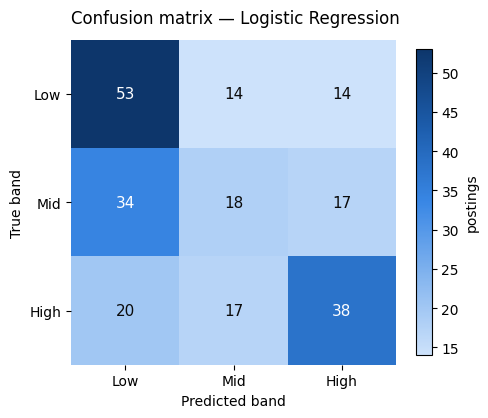

In [8]:
cm = confusion_matrix(y_test, lr_pred, labels=["Low", "Mid", "High"])
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap=BLUE_SEQUENTIAL)
ax.set_xticks(range(3)); ax.set_xticklabels(["Low", "Mid", "High"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Low", "Mid", "High"])
ax.set_xlabel("Predicted band"); ax.set_ylabel("True band")
ax.set_title("Confusion matrix — Logistic Regression", loc="left", pad=12, fontsize=12)
for i in range(3):
    for j in range(3):
        color = "white" if cm[i, j] > cm.max() / 2 else INK_PRIMARY
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=11)
ax.spines[:].set_visible(False)
plt.colorbar(im, ax=ax, shrink=0.8, label="postings")
plt.tight_layout()
plt.show()


**Insight:** the model is best at recognizing **Low**-band postings
(65% recall) and weakest at **Mid** (26% recall) — "Mid" is the hardest class
because it's the one most easily confused with its neighbors on both sides
(34 true-Mid postings were predicted Low, 17 predicted High). This is a
common and expected pattern for an ordinal 3-band split: the middle band has
no "clean" side, while Low and High each only have one neighboring class to
be confused with.


## 5. Interpretability — what actually drives the prediction

Logistic Regression's coefficients are directly interpretable: for each
class, which features push a posting toward that band.


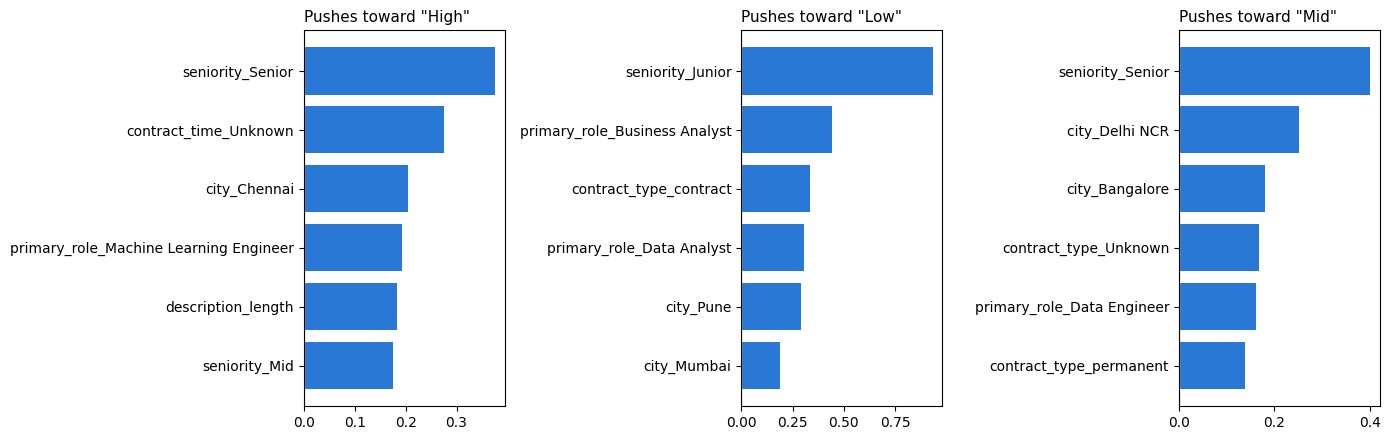

In [9]:
feature_names = lr.named_steps["pre"].get_feature_names_out()
coefs = lr.named_steps["clf"].coef_
classes = lr.named_steps["clf"].classes_

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=False)
for ax, cls, coef_row in zip(axes, classes, coefs):
    top = pd.Series(coef_row, index=feature_names).sort_values().tail(6)
    ax.barh(top.index.str.replace("cat__|num__", "", regex=True), top.values, color="#2a78d6")
    ax.set_title(f'Pushes toward "{cls}"', fontsize=11, loc="left")
    ax.axvline(0, color="#c3c2b7", linewidth=1)
plt.tight_layout()
plt.show()


**Insight:** the model has clearly learned the same story Step 4 found by
hand. The single strongest coefficient in the entire model is
`seniority_Junior -> Low` band, followed closely by `seniority_Senior ->
High` band — seniority dominates the prediction, which matches the clean
salary gradient we already saw. Beyond seniority, `primary_role` carries real
signal too: Business Analyst and Data Analyst push toward Low, Machine
Learning Engineer pushes toward High — reproducing the role-level salary
ranking from Step 4 without being told that ranking directly.


## 6. Limitations (read before trusting this model for anything real)

- **Small sample:** only 1,122 of 4,858 postings disclose salary, and the
  model is trained on an 897-row split of that. A 225-row test set means
  individual percentage points of accuracy have real sampling noise attached
  — treat "48% vs. 45%" differences between models as noise, not signal (which
  is exactly what the cross-validation step above demonstrated directly).
- **Self-selection bias:** postings that disclose salary are not a random
  sample of the market. Employers who advertise pay may skew toward larger,
  more transparent, or more competitive employers.
- **Band definitions are sample-specific:** the ₹10L/₹16L tertile cutoffs
  are a property of this 1,122-posting sample, not a fixed, reusable
  definition of "low/mid/high" salary in the Indian tech market.
- **Seniority is a derived feature, not ground truth:** it comes from
  `nlp/seniority.py`'s keyword/regex rule, not from actual HR data, so any
  systematic error in that rule (documented in that file) propagates here.
- **Correlation, not causation:** as in Step 4, skill/role features that
  predict a higher band likely proxy for experience level and company type
  as much as for the skill itself.
- **No hyperparameter tuning:** both models use sensible defaults/light
  constraints (Random Forest depth capped at 6) rather than a tuned search —
  deliberate, to keep the model choice fully explainable rather than the
  product of an opaque search.


## Key takeaways

1. Both models beat the majority-class baseline by a wide, cross-validated
   margin: **+9.8 points of accuracy, +0.268 macro-F1** over always guessing
   "Low."
2. **Random Forest looked better on one split (52.9% vs. 48.4% accuracy) but
   that advantage didn't survive cross-validation** (45.3% vs. 45.8%) — a
   direct demonstration of why a single train/test split isn't sufficient
   evidence for model selection.
3. **Logistic Regression is the final model** — equally accurate, fully
   interpretable via coefficients, and it recovers the same seniority- and
   role-driven salary story that Step 4's SQL analysis found independently,
   which is a meaningful cross-check between the two halves of this project.
